In [3]:
import numpy as np 
import pickle 
import pandas as pd 
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
from pathlib import Path
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

from default_paths import (
    FMRI_RESULTS_DIR,
    FMRI_COMPONENTS_SUMMARY_CSV,
    AUDITORY_BRAIN_DNN_ROOT,
    require_path,
)

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str as format_model_str_utils,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    strip_cochdnn9,
    get_x_labels,
    set_bar_labels
)


## Set figure out dir 

fig_out_dir = Path("./CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)

# import aud_dnn.analyze.plot_utils_AUD as plot_utils_AUD

In [4]:
fmri_eval_dir = require_path(
    FMRI_RESULTS_DIR,
    "COCHDNN_FMRI_RESULTS_DIR",
    "fMRI ridge-regression results (auditory_brain_dnn_for_audio_ssl/results)",
)

results_df = pd.read_csv(fmri_eval_dir / FMRI_COMPONENTS_SUMMARY_CSV)
results_df.source_model.unique()

array(['word_kell2018_MatchedDataset_LARS',
       'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
       'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
       'barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_latest_ckpt',
       'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01',
       'spectemp',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lm

In [5]:
def format_model_str(name):
    """Format model name using figure_utils.format_model_str, which handles all the logic."""
    if name == 'spectemp':
        return name
    if name == 'byol-a':
        return name 
    if "whisper" in name.lower():
        return name
    normalized_name, _, _, _ = format_model_str_utils(name)
    return normalized_name

In [6]:
# format_model_str already returns normalized names, so no need to normalize again
results_df['model_name_str'] = results_df.source_model.map(format_model_str)

In [7]:
# Check unique model names after normalization (for debugging)
results_df['model_name_str'].unique()

array(['CochCNN9 supervised word', 'CochCNN9 supervised multi-task',
       'CochCNN9 supervised audioset', 'CochCNN9 ssl λ=0.0',
       'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3',
       'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5',
       'CochCNN9 ssl dual λ=0.5', 'spectemp', 'CochCNN9 scaled ssl λ=0.5',
       'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled aud. event'],
      dtype=object)

# Plot Score Across Layers for Each Model

Use `plot_score_across_layers` from the analysis scripts to visualize model performance across layers.

In [8]:
# Import plot_utils_AUD functions (without modifying the .py scripts)
import sys, os
import matplotlib.pyplot as plt

# Fix for matplotlib style name change in newer versions
# 'seaborn-pastel' was renamed to 'seaborn-v0_8-pastel' in matplotlib 3.6+
# We patch plt.style.use temporarily to handle the old style names in resources.py
# Only patch if not already patched (to avoid recursion on re-run)
if not hasattr(plt.style.use, '_is_patched'):
    _original_style_use = plt.style.use

    def _patched_style_use(style):
        try:
            _original_style_use(style)
        except OSError:
            if 'seaborn' in str(style):
                try:
                    # Try the new naming convention
                    _original_style_use(style.replace('seaborn-', 'seaborn-v0_8-'))
                except OSError:
                    pass  # Skip if style not available
            else:
                raise

    _patched_style_use._is_patched = True
    plt.style.use = _patched_style_use

# Discover auditory_brain_dnn root and add module paths.
auditory_brain_dnn_root = require_path(
    AUDITORY_BRAIN_DNN_ROOT,
    "COCHDNN_AUDITORY_BRAIN_DNN_DIR",
    "auditory_brain_dnn checkout with aud_dnn/analyze/plot_utils_AUD.py",
)
aud_dnn_dir = auditory_brain_dnn_root / "aud_dnn"
aud_dnn_analyze_dir = aud_dnn_dir / "analyze"

for path in (aud_dnn_dir, aud_dnn_analyze_dir):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from plot_utils_AUD import (
    plot_score_across_layers,
    concat_dfs_modelwise,
    get_subject_pivot
    # RESULTDIR_ROOT,
    # SAVEDIR_CENTRALIZED,
)
from resources import (
    AUDIO_SSL_MODEL_LIST_2,
    d_layer_reindex,
    d_layer_names,
    d_model_names,
    d_comp_names,
    d_roi_colors,
)

# Restore original style.use after imports
if '_original_style_use' in locals():
    plt.style.use = _original_style_use

print(f"Imports successful from: {auditory_brain_dnn_root}")

RESULTDIR_ROOT = str(fmri_eval_dir)

ROOT: /mnt/ceph/users/igriffith/projects/cochdnn/auditory_brain_dnn
Imports successful from: /mnt/ceph/users/igriffith/projects/cochdnn/auditory_brain_dnn


In [9]:
AUDIO_SSL_MODEL_LIST_COCHDNN9_FIG = [
 'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
'word_kell2018_MatchedDataset_LARS',
 'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
 'kell2018_audioset_unbalanced_supervised',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
 'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
 'spectemp',
 ]

In [23]:
# Configuration for plot_score_across_layers
target = 'NH2015comp'  # Components target

# Explicit model set for this figure panel
base_models = list(AUDIO_SSL_MODEL_LIST_COCHDNN9_FIG)
extra_models = [
    'barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_latest_ckpt',  # iSSL
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
    'kell2018_audioset_unbalanced_supervised',
]
source_models = list(dict.fromkeys(base_models + extra_models))

# Explicit layer-map aliases for models missing from resources.d_layer_reindex
LAYER_TEMPLATE_MODEL = 'word_kell2018_MatchedDataset_LARS'
layer_overrides = {
    'kell2018_audioset_unbalanced_supervised': LAYER_TEMPLATE_MODEL,
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01': LAYER_TEMPLATE_MODEL,
    'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01': LAYER_TEMPLATE_MODEL,
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only': LAYER_TEMPLATE_MODEL,
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only': LAYER_TEMPLATE_MODEL,
}

# Paths - using the results directory from plot_utils_AUD
mapping = 'AUD-MAPPING-Ridge'

print(f"Target: {target}")
print(f"Number of models: {len(source_models)}")
print(f"Models: {source_models}")

Target: NH2015comp
Number of models: 15
Models: ['kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt', 'word_kell2018_MatchedDataset_LARS', 'audioset_kell2018_MatchedDataset_LARS_latest_ckpt', 'kell2018_audioset_unbalanced_supervised', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt', 'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only', 'spectemp', 'barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_au

In [24]:
# Build a combined dataframe with score, model, layer, component for all models
# Load from pre-computed across-layers CSV files (yerr is empty for components - only 1 "subject")
import os

all_results = []

# Resolve final layer mapping once (native resources + explicit aliases)
if LAYER_TEMPLATE_MODEL not in d_layer_reindex:
    raise KeyError(f"Template model {LAYER_TEMPLATE_MODEL} not found in d_layer_reindex")

layer_reindex_for_plot = dict(d_layer_reindex)
for model_name, template_model in layer_overrides.items():
    if template_model not in d_layer_reindex:
        raise KeyError(f"Template model {template_model} missing for override {model_name}")
    layer_reindex_for_plot[model_name] = d_layer_reindex[template_model]

for source_model in source_models:
    # Skip spectemp baseline for this panel
    if source_model == 'spectemp':
        continue

    if source_model not in layer_reindex_for_plot:
        print(f"Skipping {source_model} - no layer mapping available")
        continue

    layers = layer_reindex_for_plot[source_model]

    try:
        outputs_dir = Path(RESULTDIR_ROOT) / source_model / 'outputs'
        
        # Loop through each component  
        for comp in ['lowfreq', 'highfreq', 'envsounds', 'pitch', 'speech', 'music']:
            comp_name = d_comp_names[comp]
            
            # Load the across-layers CSV for this component
            csv_path = outputs_dir / f'across-layers_comp-{comp}_{source_model}_NH2015comp_median_r2_test.csv'
            
            if csv_path.exists():
                df_comp = pd.read_csv(csv_path, index_col=0)
                
                # Get scores from the 'none' row (the actual scores, not yerr)
                if 'none' in df_comp.index:
                    scores = df_comp.loc['none']
                    
                    for i, layer in enumerate(layers):
                        if layer in scores.index:
                            all_results.append({
                                'model': source_model,
                                'layer': layer,
                                'layer_idx': i,
                                'component': comp_name,
                                'comp_key': comp,
                                'score': scores[layer]
                            })
            else:
                print(f"CSV not found: {csv_path}")
        
        print(f"Processed: {source_model}")
        
    except Exception as e:
        print(f"Error processing {source_model}: {e}")
        import traceback
        traceback.print_exc()

# Create combined dataframe
df_all = pd.DataFrame(all_results)
print(f"\nCombined dataframe shape: {df_all.shape}")
print(f"Models: {df_all['model'].nunique()}")
print(f"Components: {df_all['component'].unique()}")
df_all.head(20)

Processed: kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt
Processed: word_kell2018_MatchedDataset_LARS
Processed: audioset_kell2018_MatchedDataset_LARS_latest_ckpt
Skipping kell2018_audioset_unbalanced_supervised - not in d_layer_reindex
Skipping kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01 - not in d_layer_reindex
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt
Skipping kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01 - not in d_layer_reindex
Skipping kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only - not in d_layer_reindex
Skipping kell2018_barlow_e

,model,layer,layer_idx,component,comp_key,score
0,kell2018_word_speaker_audioset_MatchedDataset_...,relu0,0,Low frequency,lowfreq,0.648453
1,kell2018_word_speaker_audioset_MatchedDataset_...,maxpool0,1,Low frequency,lowfreq,0.790997
2,kell2018_word_speaker_audioset_MatchedDataset_...,relu1,2,Low frequency,lowfreq,0.838413
3,kell2018_word_speaker_audioset_MatchedDataset_...,maxpool1,3,Low frequency,lowfreq,0.839947
4,kell2018_word_speaker_audioset_MatchedDataset_...,relu2,4,Low frequency,lowfreq,0.868817
5,kell2018_word_speaker_audioset_MatchedDataset_...,relu3,5,Low frequency,lowfreq,0.850215
6,kell2018_word_speaker_audioset_MatchedDataset_...,relu4,6,Low frequency,lowfreq,0.827009
7,kell2018_word_speaker_audioset_MatchedDataset_...,avgpool,7,Low frequency,lowfreq,0.842023
8,kell2018_word_speaker_audioset_MatchedDataset_...,relufc,8,Low frequency,lowfreq,0.771073
9,kell2018_word_speaker_audioset_MatchedDataset_...,relu0,0,High frequency,highfreq,0.632593


In [26]:
df_all['model_name_str'] = df_all.model.apply(format_model_str)

df_all.model_name_str.unique()

array(['CochCNN9 supervised multi-task', 'CochCNN9 supervised word',
       'CochCNN9 supervised audioset', 'CochCNN9 ssl λ=0.1',
       'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4',
       'CochCNN9 ssl λ=0.5', 'CochCNN9 ssl λ=0.0'], dtype=object)

# Only up to relu4

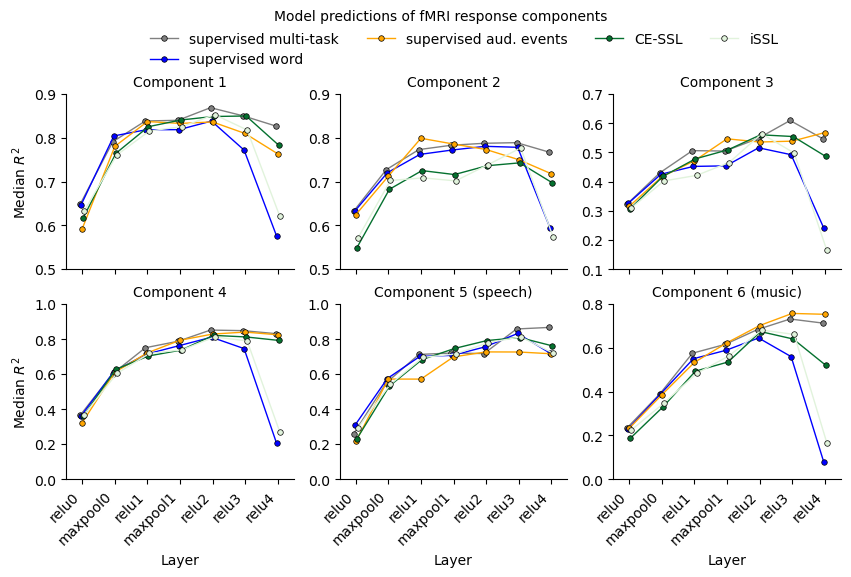

In [27]:
## Per-layer plot

# apply format_model_str to model column
to_plot = df_all.copy()
# Keep iSSL (lambda=1.0), but hide intermediate SSL lambdas and dual variants
to_plot = to_plot[~to_plot.model_name_str.str.contains("0.1|0.2|0.3|0.4|dual", na=False)]
# drop layers after relu4
to_plot = to_plot[~to_plot.layer.isin(["avgpool", "relufc"])]


hue_dict = build_model_palette(to_plot.model_name_str.unique(), get_standard_base_colors())

# Point plot: dots with model hue and black edge lines
# Create figure with extra space for legend in a "4th column"
panel_size = 2.5
title_fontsize = 10 

fig, axes = plt.subplots(2, 3, figsize=(panel_size * 4, panel_size * 2))
axes = axes.flatten()

for i, comp in enumerate(to_plot.component.unique()): 
    g = sns.pointplot(
        data=to_plot[to_plot.component == comp],
        x="layer",
        y="score",
        hue="model_name_str",
        palette=hue_dict,
        ax=axes[i],
        markers="o",
        dodge=True,
        markersize=4,
        linestyle='-',
        linewidth=1,
    )
    # Add black edges to markers
    for line in axes[i].lines:
        line.set_markeredgecolor('black')
        line.set_markeredgewidth(0.5)
        
    axes[i].set_xlabel("")
    if i > 2:
        axes[i].set_xlabel("Layer", fontsize=title_fontsize)
    axes[i].set_ylabel("", fontsize=title_fontsize)
    if i in [0,3]:
        axes[i].set_ylabel("Median $R^2$", fontsize=title_fontsize)

    title = f"Component {i+1}"
    if "Music" in comp:
        title = f"{title} (music)"
    if "Speech" in comp:
        title = f"{title} (speech)"
    axes[i].set_title(title, fontsize=title_fontsize)
    axes[i].legend().remove()
    # set xtick labels 
    axes[i].set_xticks(axes[i].get_xticks())
    x_labels = axes[i].get_xticklabels() 
    
    if i > 2:
        axes[i].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=title_fontsize)
    else:
        axes[i].set_xticklabels([""] * len(x_labels), rotation=45, ha='right', fontsize=title_fontsize)
        
    # set ytick labels
    axes[i].set_yticks(axes[i].get_yticks())
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=title_fontsize)
    sns.despine(ax=axes[i])

# Add legend spanning the right side (like a 4th column)
handles, labels = axes[0].get_legend_handles_labels()
labels = [model_label(l, use_ssl_names=True) for l in labels]
leg = fig.legend(
    handles, 
    labels, 
    loc='center right',
    bbox_to_anchor=(0.85, 0.97),
    # title='Model',
    fontsize=10,
    frameon=False,
    ncol=4,
)

# plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Make room for legend on the right
fig.suptitle("Model predictions of fMRI response components", y=1.05, fontsize=title_fontsize);
# fig.tight_layout()

# plt.savefig(fig_out_dir / "component_predictions_main_models.pdf", bbox_inches='tight',)# transparent=True)

### Voxel-wise preformance

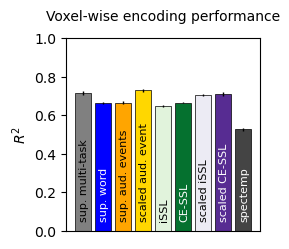

In [22]:
fname = "PLOTS_across-models/across-models_roi-None_NH2015_CV-splits-nit-10_within_subject_sem_median_r2_test_c_performance_sorted_cochdnn9fig.csv"
voxel_df = pd.read_csv(fmri_eval_dir / fname)

# Sort values in descending order by median

for_plot_df = voxel_df[~voxel_df['source_model'].str.contains("dual") & ~voxel_df['source_model'].str.startswith("barlow")]


# models to plot 
models_to_plot = [
    'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
    'word_kell2018_MatchedDataset_LARS',
    'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
    'kell2018_audioset_unbalanced_supervised',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
    "spectemp",
    
]

for_plot_df = for_plot_df[for_plot_df['source_model'].isin(models_to_plot)]

# Put models in standard order 
names = [format_model_str(n) for n in for_plot_df.source_model.values]
for_plot_df['model_name_str'] = names
std_order = get_standard_hue_order()
model_order = [m for m in std_order if m in np.unique(names)]
# Add any models in data that aren't in standard order
extra_models = [m for m in names if m not in model_order]
model_order = model_order + extra_models

# sort values for plot 
for_plot_df = for_plot_df.set_index('model_name_str').loc[model_order].reset_index()


# Build hue_dict so each formatted name is mapped correctly
names = for_plot_df.model_name_str.unique()
hue_dict = build_model_palette(names, get_standard_base_colors())
plot_names = get_x_labels(names)
plot_names = [model_label(l, use_ssl_names=True) for l in plot_names]

# Now map color to each bar using the formatted names in "names"
bar_colors = [hue_dict.get(n, '#444444') for n in names]


# bar_width = 
panel_size = 2.5
fig, axs = plt.subplots(figsize=(panel_size,panel_size))
bar_width=0.8
fontsize = 10 

bars = axs.bar(
    for_plot_df['model_name_str'].values,
    for_plot_df['median_r2_test_c_mean'].values,
    color=bar_colors,
    width=bar_width, 
    edgecolor='black',
    linewidth=0.5, 
    
)

med = for_plot_df['median_r2_test_c_mean'].values
axs.errorbar(np.arange(len(med)), 
             med, 
             yerr=for_plot_df['median_r2_test_c_yerr'].values, 
             fmt='none', 
             color='black', 
             capsize=0, 
             capthick=1, 
             elinewidth=1)

# Iterate over the bars and add text
for ix, bar in enumerate(bars):
    height = bar.get_height() 
    if height > 0.5:
        height = 0.05
    else:
        height = bar.get_height() + 0.0225
    

    bar_name = plot_names[ix].replace('supervised', 'sup.')
    text_color = "k"
    if any(sub_str in bar_name for sub_str in ["word", "CE", "spectemp"]):
        text_color = "white"
    axs.text(
        0.05 + (bar.get_x() + bar.get_width() / 2.),  # X-coordinate (center of the bar)
        height,                               # Y-coordinate (top of the bar)
        bar_name,                          # The text to display
        ha='center',                          # Horizontal alignment
        va='bottom',                          # Vertical alignment (places text slightly above)
        rotation=90,
        color=text_color,
        fontsize=fontsize-2,
    )



# axs.set_xticks(np.arange(len(med)))
axs.set_xticks([])
axs.set_xticklabels([], rotation=45, ha='right')

y_min = for_plot_df['median_r2_test_c_mean'].min() * 0.9
y_max = for_plot_df['median_r2_test_c_mean'].max()  * 1.1
axs.set_ylim(y_min, y_max)
axs.set_ylabel('$R^2$', fontsize=fontsize)
axs.set_title('Voxel-wise encoding performance', y=1.05, fontsize=fontsize);
axs.set_ylim(0,1)
axs.tick_params(axis='both', which='major', labelsize=fontsize)


# fig.tight_layout()

# plt.savefig(fig_out_dir / "voxelwise_core_models_w_spectemp.pdf", bbox_inches='tight',)# transparent=True)